# 🎓 Arquiteturas Híbridas: MobileNetV2 + LSTM + YOLO para Análise Temporal de Acidentes

**Disciplina:** Redes neurais, Deep Learning e Algoritmos Genéticos.  
**Curso:** Tecnólogo em Inteligência Artificial

### Objetivos de aprendizagem
- explicar por que combinar **CNN** e **LSTM** em um problema visual temporal;
- usar **MobileNetV2** como extrator visual leve;
- incorporar **YOLO** como pré-processamento;
- comparar um modelo híbrido especializado com o **Gemini**;
- interpretar o efeito da informação temporal na classificação de acidentes.

> **Dataset desta versão:** versão do Kaggle que contém `CrashBest` e `Crash_Table.csv`.
> Não dependemos de `Crash-1500.txt` nem de uma pasta `Normal`. As classes `NORMAL` e `CRASH` são construídas a partir da posição do acidente registrada em `Crash_Table.csv`.


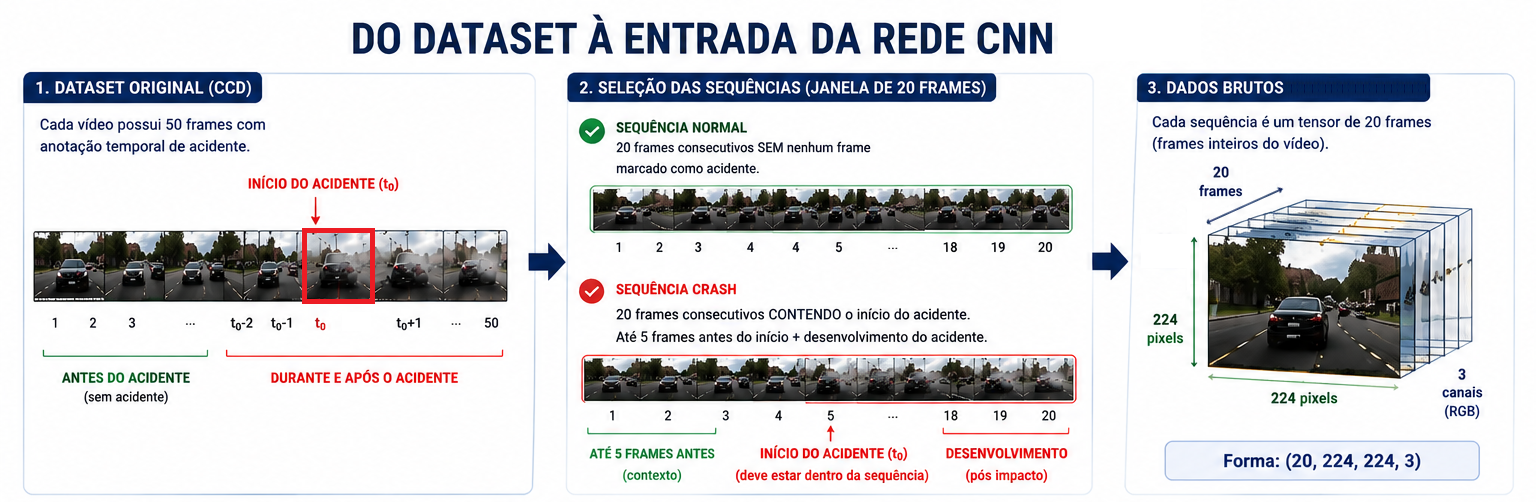

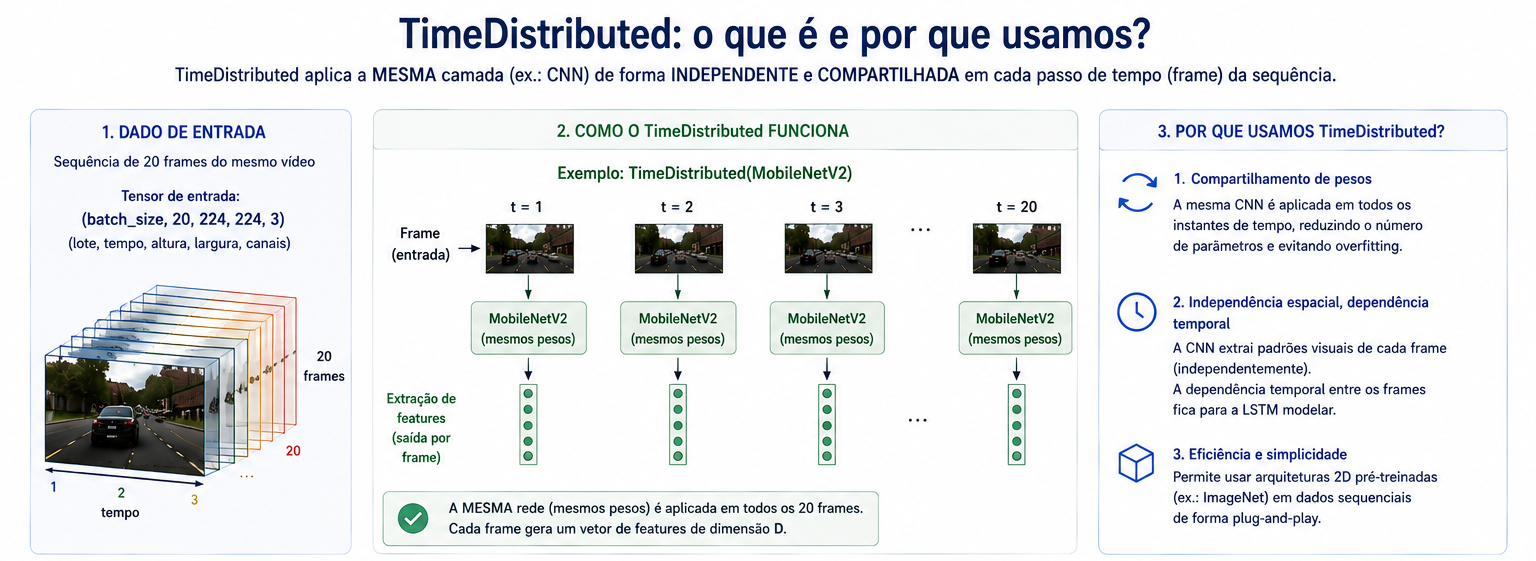

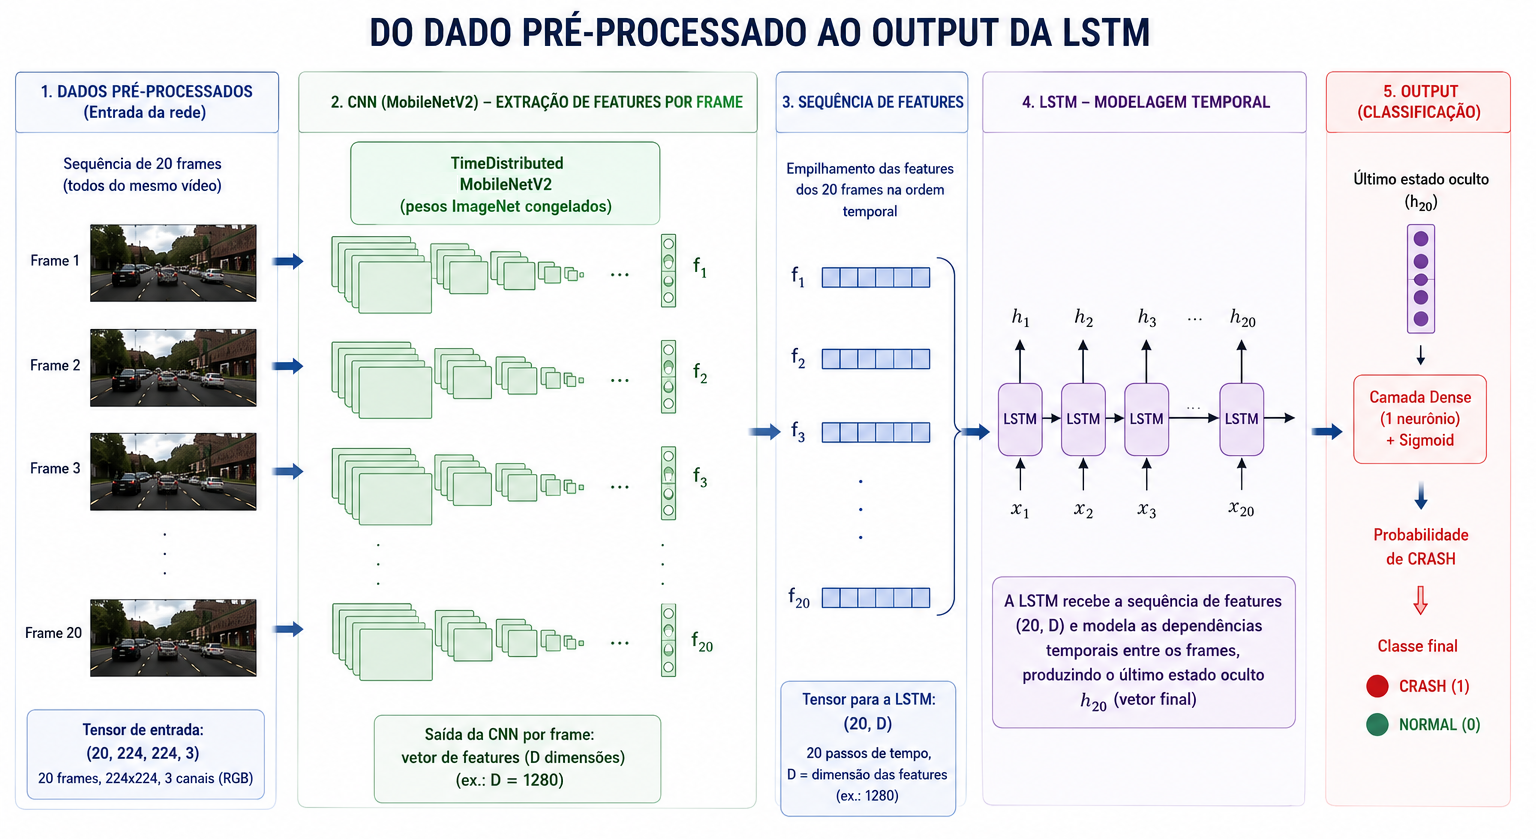

# 1. Configurando dataset e ambiente

O CCD original possui vídeos de acidente com **50 frames** e uma anotação temporal (`binlabels`) indicando quais frames contêm o acidente. O notebook usa essa informação para criar amostras temporais `NORMAL` e `CRASH` diretamente dos vídeos de acidente.

### Como a classe é construída

Para uma sequência de `SEQ_LEN` frames:

- `NORMAL` → todos os frames da janela possuem `binlabel = 0`;
- `CRASH` → pelo menos um frame da janela possui `binlabel = 1`.

A seleção é feita por **vídeo de origem**, e não por frame, evitando vazamento entre treino, validação e teste.

`MAX_SAMPLES_PER_CLASS = 500` significa até **500 sequências NORMAL + 500 sequências CRASH**.


In [ ]:
# Instalação das dependências
!pip -q install -U kagglehub ultralytics google-genai opencv-python-headless


In [ ]:
import sys
print("Python:", sys.version.split()[0])

try:
    import tensorflow as tf
    print("TensorFlow:", tf.__version__)
    print("GPU:", tf.config.list_physical_devices("GPU"))
except Exception:
    print("TensorFlow ainda não está disponível.")


In [ ]:
import os
import re
import time
import random
import shutil
from pathlib import Path
from collections import Counter

import cv2
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = 192
SEQ_LEN = 20
PRE_CRASH_FRAMES = 5
DISPLAY_FRAMES = 8
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 25

# Número de SEQUÊNCIAS por classe.
# O notebook tenta obter até 500 NORMAL + 500 CRASH.
MAX_SAMPLES_PER_CLASS = 300

CLASS_NAMES = {0: "NORMAL", 1: "CRASH"}


# 2. Baixando e inspecionando o CCD

Nesta versão usamos a estrutura disponibilizada pelo Kaggle com:

- `CrashBest/` → frames dos 1.500 vídeos de acidente;
- `Crash_Table.csv` → tabela com informações temporais do acidente.

A ideia é construir exemplos temporais a partir de um mesmo conjunto de vídeos:

- **NORMAL** → janela totalmente anterior ao início do acidente;
- **CRASH** → janela que intercepta a faixa de frames do acidente.

Isso evita depender da pasta `Normal` ou do arquivo externo `Crash-1500.txt`.


In [ ]:
DATASET_HANDLE = "asefjamilajwad/car-crash-dataset-ccd"
DATASET_ROOT = Path(kagglehub.dataset_download(DATASET_HANDLE))

print("Dataset:", DATASET_ROOT)

# Localiza a pasta CrashBest e a tabela Crash_Table.csv de forma robusta.
crashbest_candidates = [p for p in DATASET_ROOT.rglob("*") if p.is_dir() and p.name.lower() == "crashbest"]
if not crashbest_candidates:
    raise FileNotFoundError(f"Pasta CrashBest não encontrada em {DATASET_ROOT}")
CRASHBEST_DIR = sorted(crashbest_candidates, key=lambda p: len(p.parts))[0]

crash_table_candidates = [p for p in DATASET_ROOT.rglob("*") if p.is_file() and p.name.lower() == "crash_table.csv"]
if not crash_table_candidates:
    raise FileNotFoundError(f"Crash_Table.csv não encontrado em {DATASET_ROOT}")
CRASH_TABLE_PATH = sorted(crash_table_candidates, key=lambda p: len(p.parts))[0]

print("CrashBest:", CRASHBEST_DIR)
print("Crash_Table:", CRASH_TABLE_PATH)

image_files = [
    p for p in CRASHBEST_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg", ".png"}
]

print("Total de frames em CrashBest:", len(image_files))
print("Exemplos:")
for p in image_files[:10]:
    print(" ", p.relative_to(CRASHBEST_DIR))

crash_table = pd.read_csv(CRASH_TABLE_PATH)
print("\nDimensão Crash_Table.csv:", crash_table.shape)
print("Colunas:")
print(list(crash_table.columns))
print("\nPrimeiras linhas:")
display(crash_table.head())



In [ ]:
# 2.1 Organizando os frames de CrashBest

FRAME_RE = re.compile(r"^(?P<label>C)_(?P<video>\d{6})_(?P<frame>\d{2})$", re.IGNORECASE)

records = []
for image_path in image_files:
    match = FRAME_RE.match(image_path.stem)
    if not match:
        continue
    records.append({
        "source_video_id": match.group("video"),
        "frame_idx": int(match.group("frame")),
        "image_path": str(image_path)
    })

frame_df_all = (
    pd.DataFrame(records)
    .sort_values(["source_video_id", "frame_idx"])
    .reset_index(drop=True)
)

if frame_df_all.empty:
    raise ValueError("Nenhum frame C_000000_00 foi encontrado em CrashBest.")

print("Frames válidos:", len(frame_df_all))
print("Vídeos de origem:", frame_df_all.source_video_id.nunique())
print("Frames por vídeo (min/max):", frame_df_all.groupby("source_video_id").size().min(), frame_df_all.groupby("source_video_id").size().max())



# 3. Interpretando o Crash_Table.csv

# A versão do Kaggle pode usar nomes de coluna ligeiramente diferentes.
# Primeiro normalizamos os nomes e tentamos identificar automaticamente:
# (1) ID do vídeo; (2) frame inicial do acidente; (3) frame final, quando disponível.

In [ ]:


def norm_col(c):
    return re.sub(r"[^a-z0-9]", "", str(c).lower())

norm_map = {c: norm_col(c) for c in crash_table.columns}

def find_column(candidates, required=True):
    for c in crash_table.columns:
        n = norm_map[c]
        if n in candidates:
            return c
    for c in crash_table.columns:
        n = norm_map[c]
        if any(term in n for term in candidates):
            return c
    if required:
        raise KeyError(f"Não foi possível identificar coluna entre: {candidates}. Colunas disponíveis: {list(crash_table.columns)}")
    return None

video_col = find_column({"vidname", "videoid", "video", "videoname", "id", "name", "filename", "file"})
start_col = find_column({"startframe", "start", "crashframe", "accidentframe", "impactframe", "eventframe", "crashstart", "accidentstart", "startindex"})
end_col = find_column({"endframe", "end", "crashend", "accidentend", "eventend", "endindex"}, required=False)

print("Coluna ID do vídeo:", video_col)
print("Coluna início do acidente:", start_col)
print("Coluna fim do acidente:", end_col)

# Converte IDs como 1 / 18 / 000018 para o formato usado nos frames: 000018.
def normalize_video_id(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    m = re.search(r"(\d{1,6})", s)
    return m.group(1).zfill(6) if m else None

annotations = crash_table.copy()
annotations["source_video_id"] = annotations[video_col].apply(normalize_video_id)
annotations["accident_start"] = pd.to_numeric(annotations[start_col], errors="coerce")
if end_col is not None:
    annotations["accident_end"] = pd.to_numeric(annotations[end_col], errors="coerce")
else:
    # Caso a tabela contenha somente um frame do evento, usamos esse frame como centro
    # da janela de acidente.
    annotations["accident_end"] = annotations["accident_start"]

annotations = annotations.dropna(subset=["source_video_id", "accident_start"]).copy()
annotations["source_video_id"] = annotations["source_video_id"].astype(str)
annotations["accident_start"] = annotations["accident_start"].round().astype(int)
annotations["accident_end"] = annotations["accident_end"].fillna(annotations["accident_start"]).round().astype(int)

# Garante ordem e limita aos 50 frames disponíveis.
annotations["accident_start"] = annotations["accident_start"].clip(1, 50)
annotations["accident_end"] = annotations["accident_end"].clip(1, 50)
annotations["accident_end"] = np.maximum(annotations["accident_end"], annotations["accident_start"])

# Uma anotação por vídeo. Se houver duplicatas, preservamos a primeira após limpeza.
annotations = annotations.drop_duplicates("source_video_id", keep="first").reset_index(drop=True)

print("Vídeos anotados:", len(annotations))
print("Exemplos de anotação:")
display(annotations[["source_video_id", "accident_start", "accident_end"]].head(10))



In [ ]:
# 4. Construindo sequências temporais NORMAL e CRASH a partir do Crash_Table.csv

SEQ_LEN = 20
PRE_CRASH_FRAMES = 5
MAX_SAMPLES_PER_CLASS = 300

# Marca cada frame de acordo com a faixa de acidente anotada na tabela.
frame_df_annotated = frame_df_all.merge(
    annotations[["source_video_id", "accident_start", "accident_end"]],
    on="source_video_id", how="inner"
)
frame_df_annotated["event_frame_label"] = frame_df_annotated.apply(
    lambda r: int(r.accident_start <= r.frame_idx <= r.accident_end), axis=1
)

print("Frames após cruzamento com Crash_Table.csv:", len(frame_df_annotated))
print("Vídeos alinhados:", frame_df_annotated.source_video_id.nunique())

# -------------------------------------------------------------------------
# Estratégia temporal
# -------------------------------------------------------------------------
# NORMAL:
#   20 frames consecutivos, todos ANTES do início do acidente.
#   Para manter contexto de direção, escolhemos uma janela próxima do evento.
#
# CRASH:
#   20 frames consecutivos contendo o INÍCIO do acidente e seu desenvolvimento.
#   Por padrão, usamos até 5 frames antes do início + o restante após o início.
#   Se o acidente estiver muito no fim do vídeo, a janela é deslocada para a
#   esquerda para manter exatamente 20 frames e ainda conter o início.

candidate_rows = []

for source_video_id, rows in frame_df_annotated.groupby("source_video_id"):
    rows = rows.sort_values("frame_idx").reset_index(drop=True)
    if len(rows) < SEQ_LEN:
        continue

    start_event = int(rows.accident_start.iloc[0])
    end_event = int(rows.accident_end.iloc[0])
    max_frame = int(rows.frame_idx.max())
    min_frame = int(rows.frame_idx.min())

    # -------------------------
    # NORMAL: 20 frames sem acidente
    # -------------------------
    if start_event - min_frame >= SEQ_LEN:
        normal_end = start_event - 1
        normal_start = normal_end - SEQ_LEN + 1
        normal_rows = rows[(rows.frame_idx >= normal_start) & (rows.frame_idx <= normal_end)].copy()
        if len(normal_rows) == SEQ_LEN and int(normal_rows.event_frame_label.sum()) == 0:
            candidate_rows.append({
                "source_video_id": source_video_id,
                "start_frame": int(normal_rows.frame_idx.min()),
                "end_frame": int(normal_rows.frame_idx.max()),
                "event_start": start_event,
                "event_end": end_event,
                "n_event_frames": int(normal_rows.event_frame_label.sum()),
                "has_crash": 0,
                "class_name": "NORMAL",
                "paths": list(normal_rows.image_path),
                "selection_reason": "20 frames consecutivos antes do acidente"
            })

    # -------------------------
    # CRASH: início + desenvolvimento
    # -------------------------
    crash_start = max(min_frame, start_event - PRE_CRASH_FRAMES)
    crash_end = crash_start + SEQ_LEN - 1

    # Se a janela ultrapassar o fim do vídeo, desloca para a esquerda.
    if crash_end > max_frame:
        crash_end = max_frame
        crash_start = crash_end - SEQ_LEN + 1

    # Garante exatamente SEQ_LEN frames.
    if crash_start < min_frame:
        crash_start = min_frame
        crash_end = crash_start + SEQ_LEN - 1

    crash_rows = rows[(rows.frame_idx >= crash_start) & (rows.frame_idx <= crash_end)].copy()

    contains_event_start = bool((crash_rows.frame_idx == start_event).any())
    n_event_frames = int(crash_rows.event_frame_label.sum())

    if len(crash_rows) == SEQ_LEN and contains_event_start and n_event_frames >= 1:
        candidate_rows.append({
            "source_video_id": source_video_id,
            "start_frame": int(crash_rows.frame_idx.min()),
            "end_frame": int(crash_rows.frame_idx.max()),
            "event_start": start_event,
            "event_end": end_event,
            "n_event_frames": n_event_frames,
            "has_crash": 1,
            "class_name": "CRASH",
            "paths": list(crash_rows.image_path),
            "selection_reason": f"janela ancorada no início do acidente ({PRE_CRASH_FRAMES} frames antes)"
        })

candidates_df = pd.DataFrame(candidate_rows)
if candidates_df.empty:
    raise ValueError("Nenhuma sequência temporal válida foi criada. Verifique CrashBest e Crash_Table.csv.")

print("================ CANDIDATOS ================")
print("Sequências candidatas:", len(candidates_df))
print("Por classe:")
print(candidates_df.class_name.value_counts())
print("Vídeos candidatos por classe:")
print(candidates_df[["source_video_id", "class_name"]].drop_duplicates().class_name.value_counts())

# -------------------------------------------------------------------------
# Seleção balanceada e sem vazamento
# -------------------------------------------------------------------------
# Uma origem de vídeo só pode gerar UMA sequência no conjunto final.
# Primeiro selecionamos CRASH; NORMAL usa somente vídeos ainda não utilizados.
rng = np.random.RandomState(SEED)
used_source_ids = set()
selected_rows = []

def select_one_sequence_per_source(sub, target_n, used_ids, cls):
    available = sub[~sub.source_video_id.isin(used_ids)].copy()
    source_ids = available.source_video_id.drop_duplicates().to_numpy()
    rng.shuffle(source_ids)
    source_ids = source_ids[:target_n]

    chosen = []
    for source_vid in source_ids:
        one = available[available.source_video_id == source_vid]
        # Há no máximo uma sequência por classe/origem nesta construção.
        chosen.append(one.iloc[0].to_dict())
    return chosen, set(source_ids)

# CRASH primeiro
crash_rows, crash_ids = select_one_sequence_per_source(
    candidates_df[candidates_df.has_crash == 1],
    MAX_SAMPLES_PER_CLASS,
    used_source_ids,
    cls=1
)
selected_rows.extend(crash_rows)
used_source_ids.update(crash_ids)

# NORMAL somente em vídeos de origem que ainda não foram usados para CRASH
normal_rows, normal_ids = select_one_sequence_per_source(
    candidates_df[candidates_df.has_crash == 0],
    MAX_SAMPLES_PER_CLASS,
    used_source_ids,
    cls=0
)
selected_rows.extend(normal_rows)
used_source_ids.update(normal_ids)

sample_df = pd.DataFrame(selected_rows).reset_index(drop=True)
sample_df["video_id"] = sample_df.apply(
    lambda r: f"{r.source_video_id}_{r.class_name}_{int(r.start_frame):02d}", axis=1
)

print("================ CHECKPOINT ================")
print("Sequências selecionadas:", len(sample_df))
print("Por classe:")
print(sample_df.class_name.value_counts())
print("Vídeos de origem únicos:", sample_df.source_video_id.nunique())

crash_sources = set(sample_df.loc[sample_df.has_crash == 1, "source_video_id"])
normal_sources = set(sample_df.loc[sample_df.has_crash == 0, "source_video_id"])
source_overlap = crash_sources & normal_sources
print("Interseção CRASH/NORMAL por vídeo de origem:", len(source_overlap))

if source_overlap:
    raise RuntimeError(f"Vazamento detectado entre CRASH e NORMAL: {sorted(source_overlap)[:10]}")

# Reconstroi frame_df apenas com as sequências selecionadas.
# event_frame_label mantém a anotação original para permitir visualizações didáticas.
sample_frame_rows = []
for _, sample in sample_df.iterrows():
    start_event = int(sample.event_start)
    end_event = int(sample.event_end)
    for order, path in enumerate(sample.paths):
        frame_idx = int(sample.start_frame) + order
        sample_frame_rows.append({
            "video_id": sample.video_id,
            "source_video_id": sample.source_video_id,
            "frame_idx": frame_idx,
            "image_path": path,
            "event_frame_label": int(start_event <= frame_idx <= end_event),
            "has_crash": int(sample.has_crash),
            "class_name": sample.class_name,
            "event_start": start_event,
            "event_end": end_event,
        })

frame_df = pd.DataFrame(sample_frame_rows)

video_df = sample_df[[
    "video_id", "source_video_id", "has_crash", "class_name",
    "start_frame", "end_frame", "event_start", "event_end", "n_event_frames",
    "selection_reason"
]].copy()

print("Tabela final de quantidades:")
print(video_df.class_name.value_counts())

if len(video_df) < 2 * MAX_SAMPLES_PER_CLASS:
    print(
        f"ATENÇÃO: foram encontradas apenas {len(video_df)} sequências. "
        "Isso ocorre se a versão do dataset possuir menos vídeos com janela temporal válida."
    )


# 5. Visualizando exemplos das duas classes

Cada amostra agora possui **20 frames reais e consecutivos**.

- **NORMAL:** os 20 frames estão antes do início do acidente e nenhum deles possui label temporal de acidente.
- **CRASH:** os 20 frames são ancorados no início do acidente, incluindo até 5 frames de contexto antes do evento e o seu desenvolvimento imediatamente depois.

Para a visualização, mostramos apenas **8 frames representativos** da sequência para manter a figura legível. O modelo, porém, recebe os **20 frames completos**.

Isso torna a motivação da arquitetura híbrida mais clara: a MobileNetV2 extrai características visuais de cada frame e a LSTM aprende a evolução temporal do evento.

In [ ]:
def get_video_frames(video_id):
    rows = frame_df[frame_df.video_id == video_id].sort_values("frame_idx")
    return rows.reset_index(drop=True)

def sample_sequence_rows(video_id, seq_len=SEQ_LEN):
    """Retorna os frames reais da sequência selecionada para a amostra."""
    rows = get_video_frames(video_id)
    if len(rows) <= seq_len:
        return rows.reset_index(drop=True)
    idxs = np.linspace(0, len(rows) - 1, seq_len).round().astype(int)
    return rows.iloc[idxs].reset_index(drop=True)

def display_sequence_rows(rows, n_display=DISPLAY_FRAMES):
    rows = rows.reset_index(drop=True)
    if len(rows) <= n_display:
        return rows
    idxs = np.linspace(0, len(rows) - 1, n_display).round().astype(int)
    return rows.iloc[idxs].reset_index(drop=True)

def plot_sequence(video_id, title=None, n_display=DISPLAY_FRAMES):
    rows = display_sequence_rows(get_video_frames(video_id), n_display)
    fig, axes = plt.subplots(1, len(rows), figsize=(3.0 * len(rows), 3.8))
    if len(rows) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, rows.iterrows()):
        ax.imshow(Image.open(row.image_path).convert("RGB"))
        phase = "ACIDENTE" if row.event_frame_label else "antes"
        ax.set_title(f"Frame {row.frame_idx}{phase}", fontsize=9)
        ax.axis("off")
    sample_meta = video_df[video_df.video_id == video_id].iloc[0]
    if title is None:
        title = f"{video_id} — {sample_meta.class_name}"
    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

crash_video = video_df.loc[video_df.has_crash == 1, "video_id"].iloc[0]
normal_video = video_df.loc[video_df.has_crash == 0, "video_id"].iloc[4]

plot_sequence(crash_video, "Exemplo CRASH — 20 frames, início + desenvolvimento")
plot_sequence(normal_video, "Exemplo NORMAL — 20 frames sem acidente")


# 6. Visualizando a linha temporal e a janela selecionada



In [ ]:
example_source = video_df.iloc[0].source_video_id
example_original = frame_df_all[frame_df_all.source_video_id == example_source].sort_values("frame_idx")
example_ann = annotations[annotations.source_video_id == example_source].iloc[0]
example_sample = video_df[video_df.source_video_id == example_source].iloc[0]

plt.figure(figsize=(14, 3.0))
plt.axvspan(example_ann.accident_start, example_ann.accident_end, alpha=0.25, label="Faixa anotada do acidente")
plt.axvspan(example_sample.start_frame, example_sample.end_frame, alpha=0.18, label=f"Janela {example_sample.class_name}")
plt.scatter(example_original.frame_idx, [1] * len(example_original), s=30)
plt.yticks([1], ["frames"])
plt.xticks(range(1, 51, 5))
plt.xlabel("Frame")
plt.title(
    f"Vídeo {example_source} — acidente: {int(example_ann.accident_start)}–{int(example_ann.accident_end)} | "
    f"janela selecionada: {int(example_sample.start_frame)}–{int(example_sample.end_frame)} ({example_sample.class_name})"
)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(
    f"Janela selecionada: frames {int(example_sample.start_frame)}–{int(example_sample.end_frame)} | "
    f"classe={example_sample.class_name} | "
    f"frames anotados como acidente dentro da janela={int(example_sample.n_event_frames)}"
)

In [ ]:
train_videos, temp_videos = train_test_split(
    video_df,
    test_size=0.30,
    stratify=video_df.has_crash,
    random_state=SEED
)

val_videos, test_videos = train_test_split(
    temp_videos,
    test_size=0.50,
    stratify=temp_videos.has_crash,
    random_state=SEED
)

train_videos = train_videos.reset_index(drop=True)
val_videos = val_videos.reset_index(drop=True)
test_videos = test_videos.reset_index(drop=True)

print("Divisão por sequência, preservando o vídeo de origem como unidade de amostragem:")
for name, part in [("train", train_videos), ("val", val_videos), ("test", test_videos)]:
    print(f"\n{name}: {len(part)}")
    print(part.class_name.value_counts())

# Checagem importante: nenhum vídeo de origem deve aparecer em mais de um split.
for source_col in ["source_video_id"]:
    train_src = set(train_videos[source_col])
    val_src = set(val_videos[source_col])
    test_src = set(test_videos[source_col])
    print("\nVazamento entre splits:")
    print("train ∩ val:", len(train_src & val_src))
    print("train ∩ test:", len(train_src & test_src))
    print("val ∩ test:", len(val_src & test_src))

    if train_src & val_src or train_src & test_src or val_src & test_src:
        raise RuntimeError("Vazamento de vídeo de origem detectado entre train/val/test.")


# 7. Construindo sequências reais de frames para o LSTM

Cada amostra temporal é formada por `SEQ_LEN` frames **reais e consecutivos/amostrados do próprio vídeo**.

Não criamos múltiplas views artificiais de uma imagem. A dimensão temporal vem diretamente dos frames do CCD.

Formato final do tensor:

`(amostras, SEQ_LEN, IMG_SIZE, IMG_SIZE, 3)`

A MobileNetV2 será aplicada a cada frame via `TimeDistributed`, e a LSTM aprenderá a relação temporal entre os frames.

In [ ]:
def load_rgb(path):
    return Image.open(path).convert("RGB")

def resize_frame(path):
    """Carrega um frame real e retorna uint8; o pré-processamento da MobileNetV2 ocorre no modelo."""
    img = load_rgb(path)
    return np.asarray(
        img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR),
        dtype=np.uint8
    )

def build_sequence_dataset(video_part):
    X, y, ids = [], [], []

    for video_id in video_part.video_id:
        rows = sample_sequence_rows(video_id, SEQ_LEN)
        if len(rows) != SEQ_LEN:
            raise ValueError(f"A sequência {video_id} possui {len(rows)} frames; esperado {SEQ_LEN}.")

        sequence = np.stack([resize_frame(p) for p in rows.image_path])
        target = int(video_part.loc[video_part.video_id == video_id, "has_crash"].iloc[0])

        X.append(sequence)
        y.append(target)
        ids.append(video_id)

    return np.stack(X), np.asarray(y, dtype=np.float32), ids

X_train, y_train, train_ids = build_sequence_dataset(train_videos)
X_val, y_val, val_ids = build_sequence_dataset(val_videos)
X_test, y_test, test_ids = build_sequence_dataset(test_videos)

print("X_train:", X_train.shape, X_train.dtype)
print("X_val:  ", X_val.shape, X_val.dtype)
print("X_test: ", X_test.shape, X_test.dtype)


# 7. Exemplo de sequência que entra na rede

In [ ]:
example_idx = 0
rows = display_sequence_rows(get_video_frames(train_ids[example_idx]), DISPLAY_FRAMES)

fig, axes = plt.subplots(1, len(rows), figsize=(18, 4))
if len(rows) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, rows.iterrows()):
    ax.imshow(Image.open(row.image_path).convert("RGB"))
    phase = "ACIDENTE" if row.event_frame_label else "antes"
    ax.set_title(f"Frame {row.frame_idx} — {phase}")
    ax.axis("off")

plt.suptitle(
    f"Sequência completa: {SEQ_LEN} frames | visualização: {DISPLAY_FRAMES} frames | "
    f"vídeo = {train_ids[example_idx]} | Target = {CLASS_NAMES[int(y_train[example_idx])]}",
    fontsize=12
)
plt.tight_layout()
plt.show()


# 8. Arquitetura MobileNetV2 + LSTM

A rede é construída no mesmo padrão utilizado nas aulas anteriores, com `models.Sequential([...])`.

Componentes:
- **MobileNetV2**: extrator visual pré-treinado e congelado;
- **TimeDistributed**: aplica a mesma MobileNetV2 a cada um dos 20 frames;
- **LSTM**: integra a informação temporal;
- **Dense + Sigmoid**: classifica a sequência como `NORMAL` ou `CRASH`.

A ideia central:

`20 frames → MobileNetV2 por frame → features → LSTM → CRASH / NORMAL`

Como o conjunto de treinamento é balanceado, não é necessário aplicar ponderação de classes na loss.


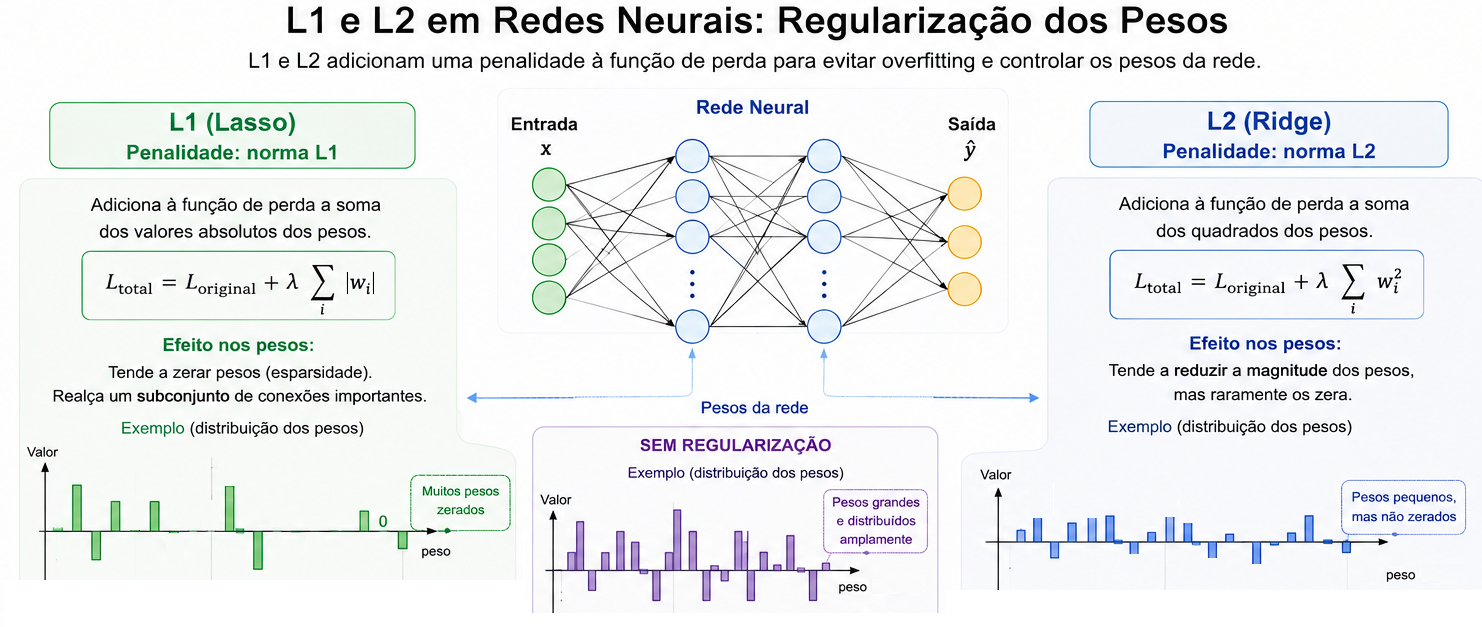

In [ ]:
def build_cnn_lstm():
    ### #todo chame a MobileNetV2 com include_top=False, weights="imagenet",
    ### input_shape=(IMG_SIZE, IMG_SIZE, 3) e pooling="avg"

    mobilenet = ...

    ### #todo congele o backbone MobileNetV3Large para que seus pesos não sejam atualizados durante o treinamento

    mobilenet.trainable = ...

    ### #todo crie um modelo Sequential contendo as camadas abaixo
    model = models.Sequential([

    ### #todo adicione uma camada Input com shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3)
    ...,

    # os pixels da imagem normalmente estão no intervalo [0, 255], e
    # precisamos transformar esses pixels no formato esperado pela pela
    # MobileNet que é o intervalo [-1, 1].
    ### TODO Para isso aplique Rescaling 1.0 / 127.5 com offset=-1.0 em cada frame usando TimeDistributed
    ### #todo nomeie a camada como "mobilenet_preprocess"
    ...,

    ### #todo aplique o backbone MobileNetV2 congelado em cada frame usando TimeDistributed
    ### #todo utilize o objeto mobilenet e nomeie a camada como "mobilenet_features"
    ...,

    ### #todo adicione LayerNormalization para normalizar as features
    ### #todo nomeie a camada como "feature_normalization"
    ...,

    ### #todo adicione SpatialDropout1D com taxa de 0.20 para regularização
    ### #todo nomeie a camada como "feature_dropout"
    ...,

    ### #todo adicione uma camada LSTM com 64 unidades, dropout=0.40 e recurrent_dropout=0.10
    ### #todo nomeie a camada como "lstm_memory"
    ...,

    ### #todo adicione uma camada Dense com 32 unidades e ativação relu
    ### #todo use regularização L2 com fator 4e-4
    ### #todo nomeie a camada como "dense_features"
    ...,

    ### #todo adicione Dropout com taxa de 0.40 e nome "dropout"
    ...,

    ### #todo adicione uma camada Dense de saída com 1 unidade e ativação sigmoid
    ### #todo nomeie a camada como "classifier"
    ...
    ], name="CNN_LSTM")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall")
        ]
    )
    return model

cnn_lstm = build_cnn_lstm()
cnn_lstm.summary()


In [ ]:
### #todo crie uma lista de callbacks para controlar o treinamento
callbacks_list = [

    ### #todo adicione EarlyStopping monitorando "val_loss"
    ### #todo use patience=8, min_delta=1e-3, restore_best_weights=True e verbose=1
    ...,

    ### #todo adicione ReduceLROnPlateau monitorando "val_loss"
    ### #todo use factor=0.8, patience=5, min_lr=1e-6 e verbose=1
    ...
]

### #todo treine o modelo cnn_lstm usando X_train e y_train
### #todo valide com validation_data=(X_val, y_val)
### #todo use epochs=EPOCHS, batch_size=BATCH_SIZE, callbacks=callbacks_list e verbose=1
history_cnn_lstm = cnn_lstm.fit(...)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn_lstm.history["loss"], label="train")
axes[0].plot(history_cnn_lstm.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_cnn_lstm.history["accuracy"], label="train")
axes[1].plot(history_cnn_lstm.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Avaliação do MobileNetV2 + LSTM


In [ ]:
def predict_binary(model, X):
    prob = model.predict(X, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return pred, prob

def metric_dict(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

pred_base, prob_base = predict_binary(cnn_lstm, X_test)
base_metrics = metric_dict(y_test, pred_base)

print(pd.Series(base_metrics).round(3))
print()
print(classification_report(
    y_test, pred_base,
    target_names=["NORMAL", "CRASH"],
    zero_division=0
))

cm = confusion_matrix(y_test, pred_base)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["NORMAL","CRASH"],
            yticklabels=["NORMAL","CRASH"])
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("MobileNetV2 + LSTM — matriz de confusão")
plt.show()


In [ ]:
# Limpeza de memória antes do YOLO
# Já calculamos as métricas do modelo base; podemos liberar os arrays grandes
# usados no treinamento para reduzir o pico de RAM no Colab.
import gc

# Benchmark do modelo base enquanto X_test ainda está disponível.
def _benchmark_local_now(model, X, repeats=3):
    _ = model.predict(X[:1], verbose=0)
    times = []
    for _ in range(repeats):
        start = time.perf_counter()
        _ = model.predict(X, verbose=0)
        times.append(time.perf_counter() - start)
    return 1000 * np.mean(times) / len(X)

lat_base_ms = _benchmark_local_now(cnn_lstm, X_test)

for _name in [
    "X_train", "X_val", "X_test",
    "y_train", "y_val"
]:
    if _name in globals():
        del globals()[_name]

# Remove objetos temporários que não são mais necessários nesta etapa.
for _name in ["history_cnn_lstm"]:
    if _name in globals():
        del globals()[_name]

# y_test é pequeno e continua sendo usado nas avaliações.
gc.collect()

print("Memória de treino liberada antes do YOLO.")
print("lat_base_ms:", None if lat_base_ms is None else round(lat_base_ms, 2), "ms/vídeo")


# 10. Adicionando YOLO como pré-processamento

Agora:

`frame → YOLO → veículo → MobileNetV2`

e depois:

`T frames → features → LSTM → CRASH / NORMAL`

Para evitar o gargalo de NMS em imagens de dashcam, usamos uma configuração enxuta: `imgsz=416`, confiança mínima `0.25`, limite de `20` detecções e filtragem direta para a classe `car` (`class_id=2`).

O YOLO será usado apenas para localizar a classe **car**.

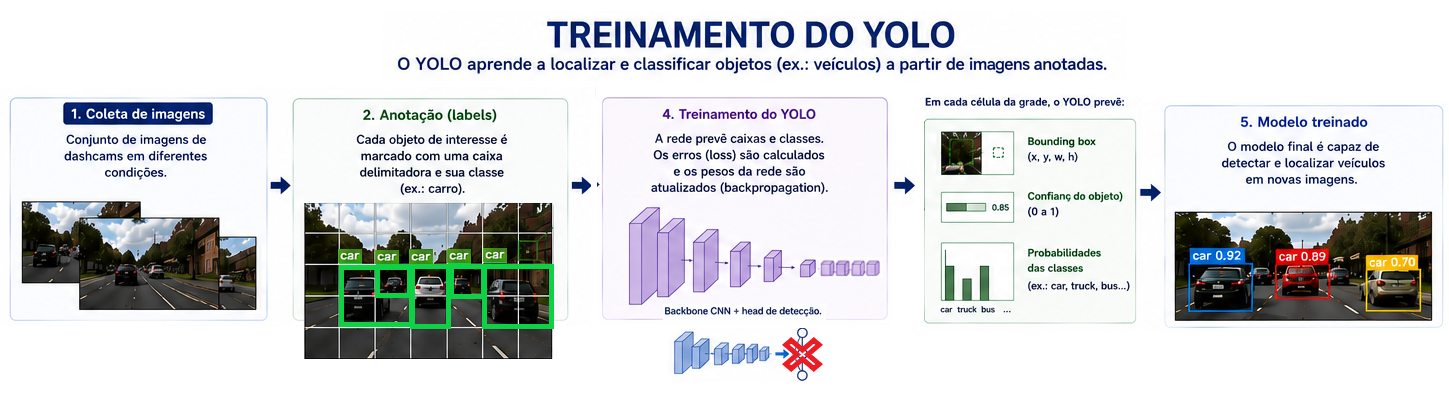

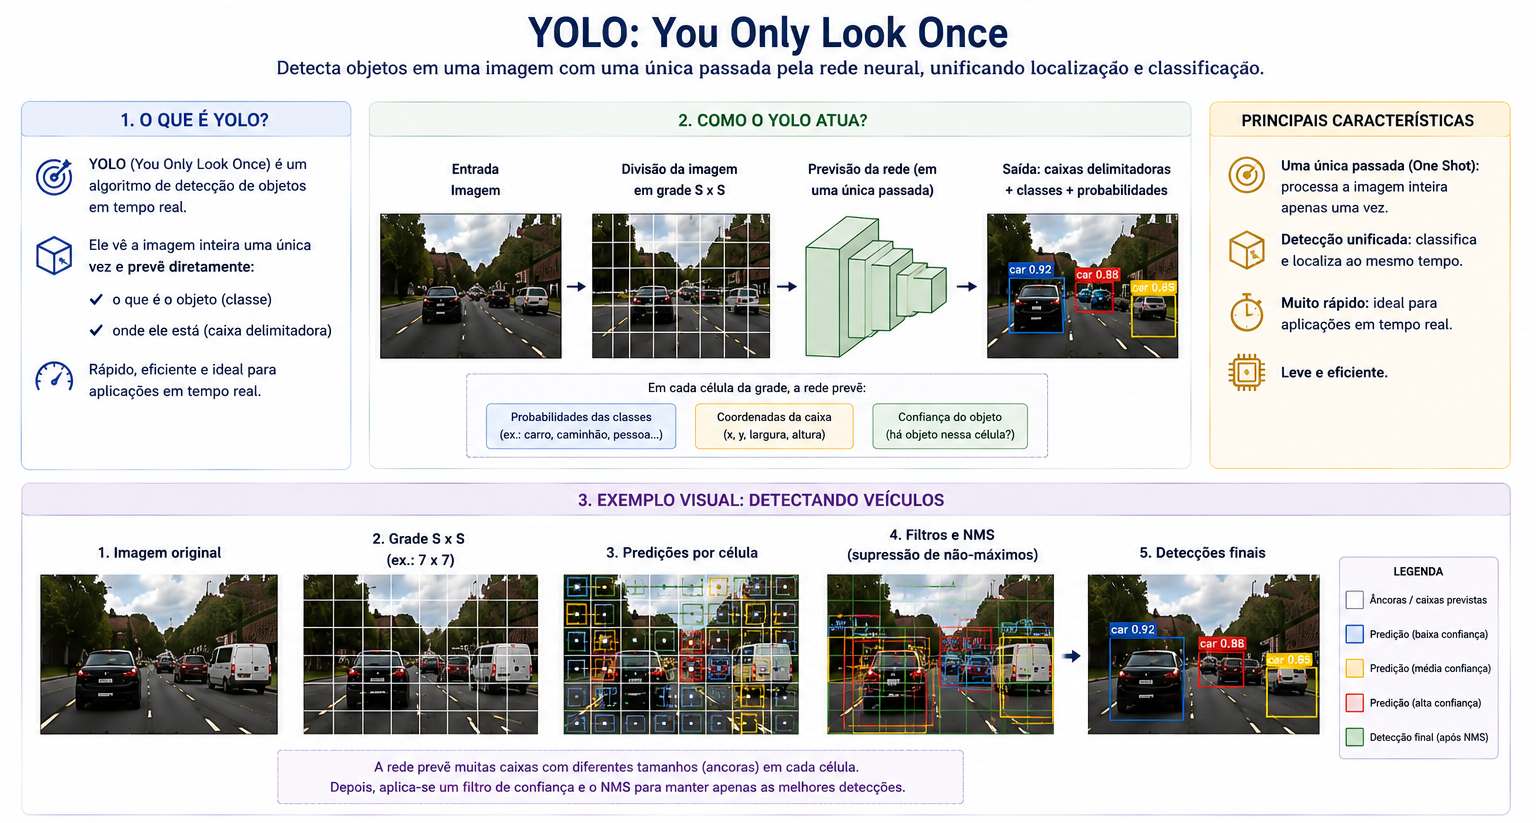

In [ ]:
from ultralytics import YOLO

# Configurações para reduzir o custo da etapa de NMS.
# O objetivo é localizar carros, então filtramos diretamente pela classe car (2).
# Modelo YOLO utilizado para detecção
YOLO_MODEL = "yolo11n.pt"

# Tamanho da imagem de entrada utilizada pelo YOLO durante a inferência.
# Valores maiores tendem a preservar mais detalhes, mas aumentam o custo computacional.
YOLO_IMGSZ = 416

# Confiança mínima para que uma detecção seja considerada válida.
# Detecções com confiança abaixo desse valor são descartadas.
YOLO_CONF = 0.25

# Limiar de IoU (Intersection over Union), que mede quanto duas caixas delimitadoras
# se sobrepõem. O NMS (Non-Maximum Suppression) utiliza esse valor para identificar
# detecções muito sobrepostas e manter apenas a detecção com maior confiança.
# Quanto menor o valor, mais facilmente caixas sobrepostas serão consideradas diferentes.
YOLO_IOU = 0.50

# Número máximo de objetos que podem ser retornados em uma única imagem.
YOLO_MAX_DET = 20

yolo = YOLO(YOLO_MODEL)
print("YOLO carregado.")
print(f"imgsz={YOLO_IMGSZ} | conf={YOLO_CONF} | iou={YOLO_IOU} | max_det={YOLO_MAX_DET} | classes=[2]")


In [ ]:
### #todo execute a predição do modelo YOLO usando a imagem como source
result = yolo.predict(
    ### #todo use image_path como source fazendo source=str(image_path),
    ...,
    ### #todo use imgsz=YOLO_IMGSZ para definir o tamanho da imagem de entrada
    ...,
    ### #todo use conf=YOLO_CONF como confiança mínima para as detecções
    ...,
    ### #todo use iou=YOLO_IOU como limiar de IoU para o NMS
    ...,
    ### #todo use max_det=YOLO_MAX_DET para limitar o número máximo de detecções
    ...,
    ### #todo restrinja a detecção somente à classe 2.
    ### # o parâmetro classes define quais classes do dataset COCO serão consideradas na detecção.
    ### # no COCO, a classe 2 corresponde a "car" (carro).
    ### # portanto, classes=[2] faz o YOLO detectar somente carros e ignorar os demais objetos.
    ...
)[0]



In [ ]:
### #todo obtenha as coordenadas das caixas delimitadoras das detecções.
### #todo result.boxes.xyxy contém as coordenadas no formato [x1, y1, x2, y2],
### #todo em que (x1, y1) representa o canto superior esquerdo e
### #todo (x2, y2) representa o canto inferior direito de cada caixa.
### #todo use .cpu() para mover os dados da GPU para a CPU e .numpy() para convertê-los em um array NumPy.
boxes_xyxy = ...
boxes_xyxy

Cada linha do array corresponde a uma detecção e contém quatro valores no formato:

$$ [x_1,\ y_1,\ x_2,\ y_2] $$

em que:

x1: coordenada horizontal do canto superior esquerdo da caixa;

y1: coordenada vertical do canto superior esquerdo da caixa;

x2: coordenada horizontal do canto inferior direito da caixa;

y2: coordenada vertical do canto inferior direito da caixa.

```text
(x1, y1) ----------------------+
|                              |
|            OBJETO            |
|                              |
+-------------------------- (x2, y2)
```

In [ ]:
### #todo obtenha a classe prevista para cada detecção.
### #todo result.boxes.cls contém o índice numérico da classe identificada pelo modelo.
### #todo use .cpu() para trazer os dados para a CPU e .numpy() para convertê-los em um array NumPy.
classes = ...
classes

In [ ]:
### #todo obtenha o nível de confiança de cada detecção.
### #todo result.boxes.conf contém um valor entre 0 e 1 indicando a confiança
### #todo do modelo de que cada caixa corresponde à classe prevista.
### #todo use .cpu() para trazer os dados para a CPU e .numpy() para convertê-los em um array NumPy.
confidences = ...
confidences

In [ ]:
def detect_vehicle_crop(
    image_path,
    conf=YOLO_CONF,
    margin=0.08,
    center_weight=0.60,
    area_weight=0.25,
    confidence_weight=0.15,
):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    result = yolo.predict(
        source=str(image_path),
        imgsz=YOLO_IMGSZ,
        conf=conf,
        iou=YOLO_IOU,
        max_det=YOLO_MAX_DET,
        classes=[2],
        verbose=False
    )[0]

    candidates = []

    # Centro esperado da imagem
    img_cx = w / 2
    img_cy = h / 2

    if result.boxes is not None:

        for box, cls_id, score in zip(
            result.boxes.xyxy.cpu().numpy(),
            result.boxes.cls.cpu().numpy(),
            result.boxes.conf.cpu().numpy()
        ):

            # Apenas carros
            if int(cls_id) != 2:
                continue

            x1, y1, x2, y2 = box

            bw = x2 - x1
            bh = y2 - y1

            if bw <= 0 or bh <= 0:
                continue

            # --------------------------------------------------
            # 1. Centro da bounding box
            # --------------------------------------------------
            box_cx = (x1 + x2) / 2
            box_cy = (y1 + y2) / 2

            # Distância normalizada até o centro da imagem
            dx = (box_cx - img_cx) / (w / 2)
            dy = (box_cy - img_cy) / (h / 2)

            distance = np.sqrt(dx**2 + dy**2)

            # Quanto mais próximo do centro, maior a pontuação
            centrality = max(0, 1 - distance)

            # --------------------------------------------------
            # 2. Área relativa do veículo
            # --------------------------------------------------
            area_ratio = (bw * bh) / (w * h)

            # --------------------------------------------------
            # 3. Confiança do YOLO
            # --------------------------------------------------
            confidence = float(score)

            # --------------------------------------------------
            # Score final
            # --------------------------------------------------
            final_score = (
                center_weight * centrality
                + area_weight * area_ratio
                + confidence_weight * confidence
            )

            candidates.append({
                "box": box,
                "confidence": confidence,
                "centrality": centrality,
                "area_ratio": area_ratio,
                "score": final_score
            })

    # ------------------------------------------------------
    # Nenhum carro encontrado
    # ------------------------------------------------------
    if not candidates:
        return img, (0, 0, w, h), 0.0

    # Escolhe o carro mais compatível com o objetivo
    best = max(
        candidates,
        key=lambda x: x["score"]
    )

    box = best["box"]
    confidence = best["confidence"]

    x1, y1, x2, y2 = box.astype(int)

    bw = x2 - x1
    bh = y2 - y1

    # ------------------------------------------------------
    # Margem ao redor do veículo
    # ------------------------------------------------------
    x1 = max(0, int(x1 - margin * bw))
    y1 = max(0, int(y1 - margin * bh))

    x2 = min(w, int(x2 + margin * bw))
    y2 = min(h, int(y2 + margin * bh))

    crop = img.crop((x1, y1, x2, y2))

    return crop, (x1, y1, x2, y2), confidence

In [ ]:
### #todo selecione o ID do vídeo localizado na linha X de train_videos.
### # utilize a coluna "video_id" para obter o identificador do vídeo
### # usando train_videos.iloc[X].video_id
YOLO_SAMPLE_ID = ...
YOLO_SAMPLE_ID

In [ ]:
### #todo obtenha uma sequência de 1 frame/imagem pertencente ao vídeo selecionado.
### #usando a função sample_sequence_rows(), passando o YOLO_SAMPLE_ID do vídeo e o número de frames desejado.
sample_rows = ...
sample_rows

In [ ]:
### TODO Faça sample_image_path como sample_rows.iloc[0].image_path
### Para pegar o caminho da imagem
sample_image_path = sample_rows.iloc[0].image_path

In [ ]:
### #todo detecte o veículo presente na imagem usando
### # detect_vehicle_crop(sample_image_path) e obtenha três informações:
### # crop: recorte da imagem contendo o veículo detectado.
### # box: coordenadas da caixa delimitadora [x1, y1, x2, y2].
### # score: nível de confiança da detecção realizada pelo modelo YOLO.
crop, box, score = ...
crop, box, score

In [ ]:
full = Image.open(sample_image_path).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(full)
x1, y1, x2, y2 = box
axes[0].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=3))
axes[0].set_title(f"YOLO — confiança: {score:.2f}")
axes[0].axis("off")

axes[1].imshow(crop)
axes[1].set_title("Crop do veículo")
axes[1].axis("off")
plt.tight_layout()
plt.show()


# 12. YOLO + MobileNetV2 + LSTM

Mantemos a mesma arquitetura neural e mudamos apenas a entrada.

Pergunta:

> **A localização explícita do veículo melhora a classificação?**

A etapa de detecção é feita frame a frame. A configuração de inferência foi reduzida para evitar avisos de NMS e o custo desnecessário de dezenas/centenas de caixas candidatas.


In [ ]:
def make_yolo_frame(image_path):
    """Detecta o veículo no frame real e retorna apenas o crop redimensionado."""
    vehicle_crop, _, _ = detect_vehicle_crop(image_path)
    return np.asarray(
        vehicle_crop.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR),
        dtype=np.uint8
    )

def build_yolo_sequence_dataset(video_part):
    X, y, ids = [], [], []

    for video_id in video_part.video_id:
        rows = sample_sequence_rows(video_id, SEQ_LEN)
        frames = [make_yolo_frame(p) for p in rows.image_path]

        X.append(np.stack(frames))
        y.append(
            int(video_part.loc[video_part.video_id == video_id, "has_crash"].iloc[0])
        )
        ids.append(video_id)

    return np.stack(X), np.asarray(y, dtype=np.uint8), ids

X_train_yolo, y_train_yolo, train_yolo_ids = build_yolo_sequence_dataset(train_videos)
X_val_yolo, y_val_yolo, val_yolo_ids = build_yolo_sequence_dataset(val_videos)
X_test_yolo, y_test_yolo, test_yolo_ids = build_yolo_sequence_dataset(test_videos)

print("X_train_yolo:", X_train_yolo.shape)
print("X_val_yolo:  ", X_val_yolo.shape)
print("X_test_yolo: ", X_test_yolo.shape)


In [ ]:
### #todo crie uma nova instância do modelo CNN-LSTM usando a função build_cnn_lstm()
### #todo armazene o modelo criado na variável cnn_lstm_yolo.
cnn_lstm_yolo = ...

### #todo treine o modelo cnn_lstm_yolo usando os dados de treinamento processados pelo YOLO.
### #todo utilize X_train_yolo como entradas e y_train_yolo como rótulos.
### #todo valide o modelo usando X_val_yolo e y_val_yolo.
### #todo utilize epochs=EPOCHS, batch_size=BATCH_SIZE e callbacks=callbacks_list.
### #todo mantenha verbose=1 para acompanhar o progresso do treinamento.
history_yolo = cnn_lstm_yolo.fit(
    ...,
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_yolo.history["loss"], label="train")
axes[0].plot(history_yolo.history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(history_yolo.history["accuracy"], label="train")
axes[1].plot(history_yolo.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
pred_yolo, prob_yolo = predict_binary(cnn_lstm_yolo, X_test_yolo)
yolo_metrics = metric_dict(y_test_yolo, pred_yolo)

comparison_nn = pd.DataFrame(
    [base_metrics, yolo_metrics],
    index=["MobileNetV2 + LSTM", "YOLO + MobileNetV2 + LSTM"]
)


display(comparison_nn.round(3))


In [ ]:
# Benchmark e limpeza da etapa YOLO
lat_yolo_ms = _benchmark_local_now(cnn_lstm_yolo, X_test_yolo)

# Liberamos os três arrays YOLO e o histórico de treino para reduzir o pico de RAM
# antes da etapa do Gemini e das visualizações.
for _name in [
    "X_train_yolo", "X_val_yolo", "X_test_yolo",
    "y_train_yolo", "y_val_yolo", "history_yolo"
]:
    if _name in globals():
        del globals()[_name]

import gc
gc.collect()
print("Memória da etapa YOLO liberada.")
print("lat_yolo_ms:", round(lat_yolo_ms, 2), "ms/vídeo")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, title, y_pred in [
    (axes[0], "MobileNetV2 + LSTM", pred_base),
    (axes[1], "YOLO + MobileNetV2 + LSTM", pred_yolo)
]:
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=["NORMAL","CRASH"],
                yticklabels=["NORMAL","CRASH"])
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_title(title)

plt.tight_layout()
plt.show()


# 13. Visualizando divergências

Uma métrica diz quanto o modelo erra. Uma imagem ajuda a entender onde ele discorda.


In [ ]:
results = test_videos.copy().reset_index(drop=True)
results["y_true"] = y_test.astype(int)
results["mobilenet_lstm_prob"] = prob_base
results["mobilenet_lstm_pred"] = pred_base
results["yolo_mobilenet_lstm_prob"] = prob_yolo
results["yolo_mobilenet_lstm_pred"] = pred_yolo

interesting = results[results.mobilenet_lstm_pred != results.yolo_mobilenet_lstm_pred].copy()
if len(interesting) == 0:
    interesting = results.sample(min(4, len(results)), random_state=SEED)
interesting = interesting.head(4)

for _, row in interesting.iterrows():
    seq_rows = display_sequence_rows(get_video_frames(row.video_id), DISPLAY_FRAMES)
    fig, axes = plt.subplots(1, len(seq_rows), figsize=(18, 4))
    if len(seq_rows) == 1:
        axes = [axes]
    for ax, (_, frame_row) in zip(axes, seq_rows.iterrows()):
        ax.imshow(Image.open(frame_row.image_path).convert("RGB"))
        phase = "ACIDENTE" if frame_row.event_frame_label else "antes"
        ax.set_title(f"Frame {frame_row.frame_idx} — {phase}", fontsize=9)
        ax.axis("off")
    plt.suptitle(
        f"{row.video_id} | Real: {CLASS_NAMES[row.y_true]} | "
        f"MobileNetV2+LSTM: {CLASS_NAMES[row.mobilenet_lstm_pred]} (p={row.mobilenet_lstm_prob:.2f}) | "
        f"YOLO+MobileNetV2+LSTM: {CLASS_NAMES[row.yolo_mobilenet_lstm_pred]} "
        f"(p={row.yolo_mobilenet_lstm_prob:.2f})",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()


# 24. Referências técnicas

- Kaggle — Car Crash Dataset (CCD): https://www.kaggle.com/datasets/asefjamilajwad/car-crash-dataset-ccd
- CarCrashDataset / Cogito2012: https://github.com/Cogito2012/CarCrashDataset
- Ultralytics — https://docs.ultralytics.com/

**Observação:** o CCD documenta 1.500 vídeos de acidentes e 3.000 vídeos normais, com 50 frames por vídeo. A versão do Kaggle usada neste notebook fornece os frames individualmente, por isso o notebook os agrupa pelo ID do vídeo.


# 🎯 Conclusão

Nesta aula prática, vimos como:
- combinar **MobileNetV2 + LSTM** para aprender informação visual e temporal;
- usar **YOLO como pré-processamento**, localizando veículos antes da classificação;
- perceber por que problemas de vídeo se beneficiam de arquiteturas que preservam a dimensão temporal.
